# ДЗ №1 СУНЦ МГУ - Numpy practice

**Среда:** Python 3.14.7. Локальные модули `functions.py` и `functions_vectorized.py` повторно импортируются при каждом запуске ячейки с решением.


### Туториальные задачи
__(9 баллов)__

Ниже приведены задачи на работу с numpy-массивами. Для каждой из задач нужно привести 2 реализации: одна без использования numpy (cчитайте, что там, где на входе или выходе должны быть numpy array, будут просто списки), а вторая полностью векторизованная (без использования питоновских циклов/map/list comprehension). Невекторизованная реализация каждой из задач оценивается в __0.5 балла__, векторизованная – в __1 балл__.

Реализации без использования векторизации нужно записать в файл functions.py, а векторизованные &mdash; в файл functions_vectorized.py

Для каждой задачи, приведённой ниже сравните скорость работы невекторизованной и векторизованной реализации. С помощью пакета matplotlib постройте графики времени работы в зависимости от размера данных. __Графики должны выглядеть опрятно!__ То есть должны быть подписаны оси, названия графиков, и т.д. Например, ниже представлены хороший и плохой графики:

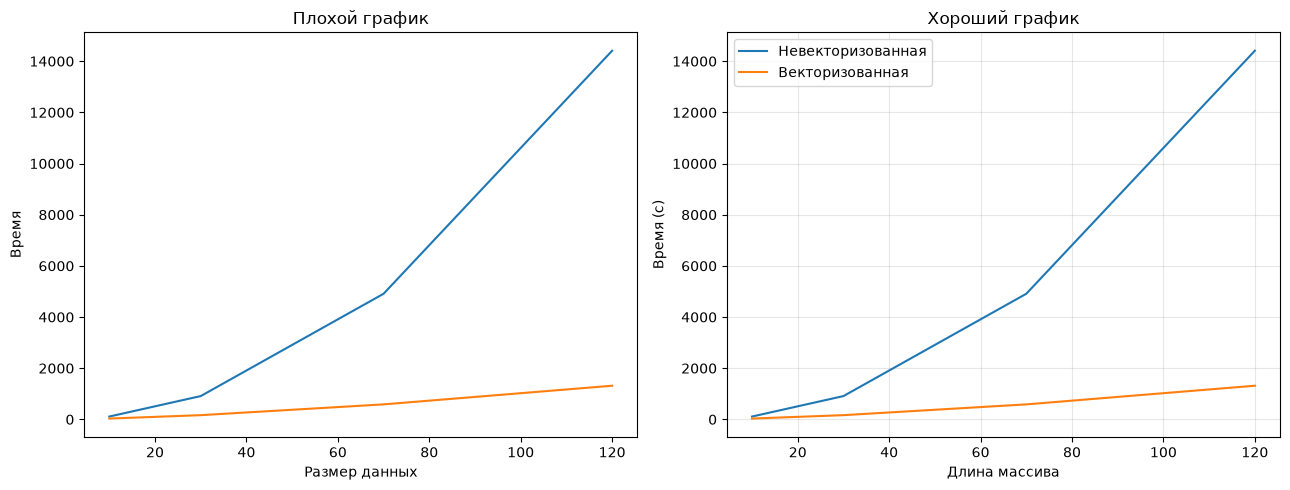

In [12]:
from importlib import reload

import matplotlib.pyplot as plt
import numpy as np

import functions
import functions_vectorized

%matplotlib inline


def reload_solution_modules():
    """Reload the two local solution modules after their files change."""
    reload(functions)
    reload(functions_vectorized)


data_size = np.array([10, 30, 70, 120])
time_non_vectorized = data_size**2 + 10
time_vectorized = data_size**1.5

figure, (axis_bad, axis_good) = plt.subplots(1, 2, figsize=(13, 5))

axis_bad.plot(data_size, time_non_vectorized)
axis_bad.plot(data_size, time_vectorized)
axis_bad.set_title("Плохой график")
axis_bad.set_xlabel("Размер данных")
axis_bad.set_ylabel("Время")

axis_good.plot(data_size, time_non_vectorized, label="Невекторизованная")
axis_good.plot(data_size, time_vectorized, label="Векторизованная")
axis_good.set_title("Хороший график")
axis_good.set_xlabel("Длина массива")
axis_good.set_ylabel("Время (с)")
axis_good.grid(True, alpha=0.3)
axis_good.legend()

figure.tight_layout()
plt.show()


* __Задача 1__: Подсчитать произведение ненулевых элементов на диагонали прямоугольной матрицы.  
 Например, для X = np.array([[1, 0, 1], [2, 0, 2], [3, 0, 3], [4, 4, 4]]) ответ – 3.

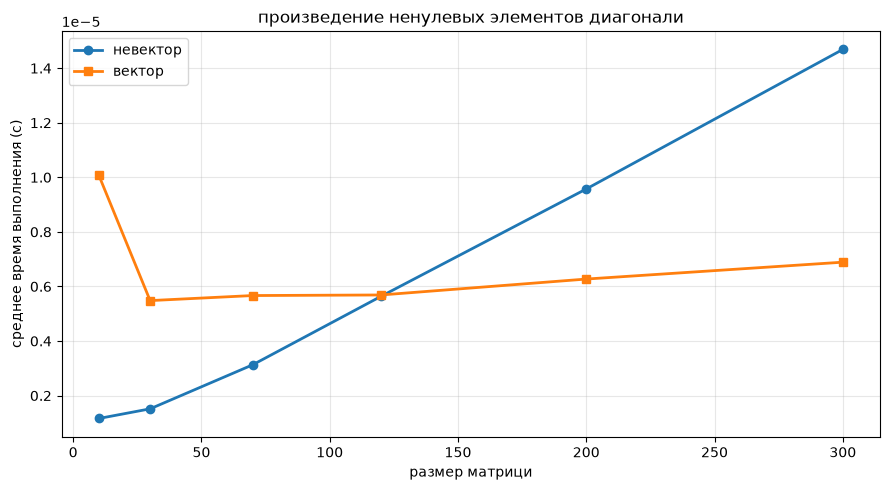

In [6]:
import timeit 
import matplotlib.pyplot as plt 
import numpy as np 
import functions
import functions_vectorized

data_sizes = np.array([10, 30, 70, 120, 200, 300])
time_not_vectorized = []
time_vectorized = []

for size in data_sizes:
    matrix = np.random.randint(0, 3, size=(size, size))
    matrix_list = matrix.tolist()

    non_vectorized_time = timeit.timeit(lambda: functions.prod_non_zero_diag(matrix_list), number=10) / 10

    vectorized_time = timeit.timeit(lambda: functions_vectorized.prod_non_zero_diag(matrix), number=10) / 10

    time_not_vectorized.append(non_vectorized_time)
    time_vectorized.append(vectorized_time)

time_not_vectorized = np.array(time_not_vectorized)
time_vectorized = np.array(time_vectorized)

figure, axis = plt.subplots(figsize=(9, 5))

axis.plot(data_sizes, time_not_vectorized, marker="o", linewidth=2, label="невектор")
axis.plot(data_sizes, time_vectorized, marker="s", linewidth=2, label="вектор")

axis.set_title("произведение ненулевых элементов диагонали")
axis.set_xlabel("размер матрици")
axis.set_ylabel("среднее время выполнения (с)")
axis.grid(True, alpha=0.3)
axis.legend()

figure.tight_layout()
plt.show()

 
 
* __Задача 2__: Даны два вектора x и y. Проверить, задают ли они одно и то же мультимножество.  
  Например, для x = np.array([1, 2, 2, 4]), y = np.array([4, 2, 1, 2]) ответ – True.
  
  


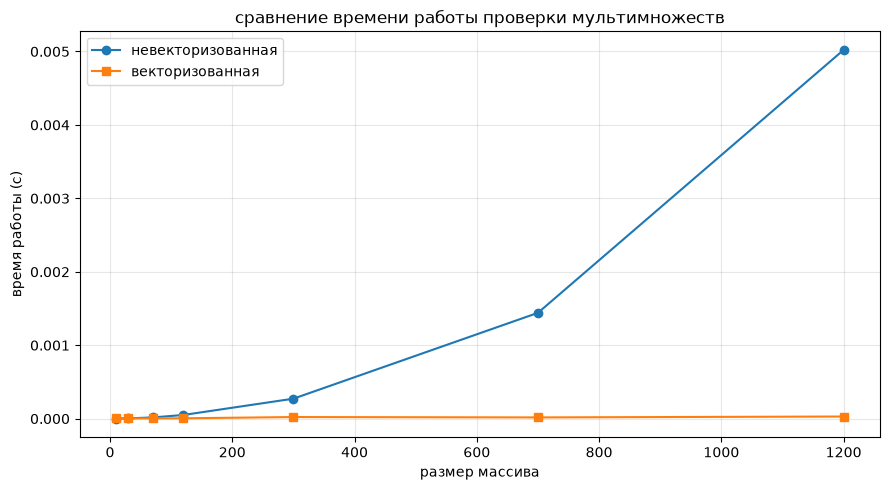

In [8]:
  import time
  import matplotlib.pyplot as plt
  import numpy as np
  import functions
  import functions_vectorized
  from importlib import reload
  %matplotlib inline

  def reload_solution_modules():
      reload(functions)
      reload(functions_vectorized)

  reload_solution_modules()
  data_size = np.array([10, 30, 70, 120, 300, 700, 1200])
  time_non_vectorized = []
  time_vectorized = []

  for size in data_size:
      x = np.arange(size)
      y = x[::-1]
      repetitions = 5

      start = time.perf_counter()
      for _ in range(repetitions):
          functions.are_multisets_equal(x.tolist(), y.tolist())
      time_non_vectorized.append((time.perf_counter() - start) / repetitions)

      start = time.perf_counter()
      for _ in range(repetitions):
          functions_vectorized.are_multisets_equal(x, y)
      time_vectorized.append((time.perf_counter() - start) / repetitions)

  plt.figure(figsize=(9, 5))

  plt.plot(
      data_size,time_non_vectorized,marker="o",label="невекторизованная")

  plt.plot(data_size,time_vectorized,marker="s",label="векторизованная")

  plt.title("сравнение времени работы проверки мультимножеств")
  plt.xlabel("размер массива")
  plt.ylabel("время работы (с)")
  plt.grid(True, alpha=0.3)
  plt.legend()
  plt.tight_layout()
  plt.show()

* __Задача 3__: Найти максимальный элемент в векторе x среди элементов, перед которыми стоит нулевой.  
 Например, для x = np.array([6, 2, 0, 3, 0, 0, 5, 7, 0]) ответ – 5.

In [4]:
reload_solution_modules()

# code here


 
 
* __Задача 4__: Дан трёхмерный массив, содержащий изображение, размера (height, width, numChannels), а также вектор длины numChannels. Сложить каналы изображения с указанными весами, и вернуть результат в виде матрицы размера (height, width). В ноутбуке приведите пример работы функции – преобразуйте цветное изображение в оттенки серого, использовав коэффициенты np.array([0.299, 0.587, 0.114]). Считать реальное изображение можно с помощью `PIL.Image.open` из пакета Pillow: `img = np.asarray(Image.open(path).convert("RGB"))`. Устаревшая функция `scipy.misc.imread` удалена из современных версий SciPy.


In [5]:
reload_solution_modules()

# code here


* __Задача 5__: Реализовать кодирование длин серий (Run-length encoding). Для некоторого вектора x необходимо вернуть кортеж из двух векторов одинаковой длины. Первый содержит числа, а второй - сколько раз их нужно повторить.  
 Например, для x = np.array([2, 2, 2, 3, 3, 3, 5]) ответ – (np.array([2, 3, 5]), np.array([3, 3, 1])).

In [1]:
reload_solution_modules()

# code here

NameError: name 'reload_solution_modules' is not defined

 
 
* __Задача 6__: Даны две выборки объектов - X и Y. Вычислить матрицу евклидовых расстояний между объектами. Дополнительно сравните с функцией scipy.spatial.distance.cdist по скорости работы (сравнения приведите ниже в ноутбуке).

In [7]:
reload_solution_modules()

# code here


### Туториал по Markdown

__(1 балл)__

Напишите краткий (а в данной домашке ещё и почти бесмысленный) отчёт с использованием 4-5 различных вариантов разметки/выделения текста.

In [8]:
# code here